# Employee Satisfaction & Attrition Prediction

# Описание проекта
HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.

Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён. 
Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли. 

У нас будет несколько задач: 
1. Построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. 
2. Построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

# Загрузка необходимых библиотек

In [133]:
!pip install phik

In [2]:
# загружаем основные библиотеки для работы с данными
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from phik import phik_matrix
from phik.report import plot_correlation_matrix

# загружаем библиотеки для построения модели
from sklearn.model_selection import train_test_split

# загружаем класс pipeline
from sklearn.pipeline import Pipeline

# загружаем классы для подготовки данных
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer

# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer

# загружаем функцию для работы с метриками
from sklearn.metrics import recall_score, make_scorer, roc_auc_score

# импортируем класс GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# загружаем нужные модели
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyRegressor
from lightgbm import LGBMRegressor

In [135]:
RANDOM_STATE = 42

## Задача 1

### Загрузка данных

Загрузим данные, которые передали нам заказчики.

In [136]:
job_satisfaction_rate = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
test_features = pd.read_csv('/datasets/test_features.csv')
test_target_job_satisfaction_rate = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')

Проверим корректность считывания.

In [137]:
display(job_satisfaction_rate.head())
display(test_features.head())
test_target_job_satisfaction_rate.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


Все считалось корректно, теперь выведем общую информацию о каждой таблице.

In [138]:
display(job_satisfaction_rate.info())
display(test_features.info())
test_target_job_satisfaction_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


Присутствуют пропуски в тренировочных и тестовых данных, их заполнением мы займемся при создании пайплайна. Названия и описания столбцов соответствуют типам данным.

**Вывод:** Обнаружены пропуски в данных, в остальном плане все качественно. Насколько качественно - оценим в предобработке.

### Предобработка данных

Обрабатывать каждую таблицу будем поочередно. Не будем заполнять пропуски, заполним их в пайплане. Займемся дубликатами, аномальными значениями и т.д.

Введем функцию для обработки явных дубликатов.

In [139]:
def del_duplicates(df, show_duplicates=True):
    if show_duplicates==True:
        print('Всего дубликатов:', df.duplicated().sum())
        display(df[df.duplicated()])
    return df.drop_duplicates()

Введем функцию для анализа количественных признаков.

In [140]:
def numeric_describe(df, boxplots=True):
    columns = df.select_dtypes(include='number').columns.tolist()
    del columns[0]
    display(df[columns].describe())
    if boxplots:
        for column in columns:
            df[column].plot(kind='box', figsize=(5, 3))
            plt.ylabel('Значения')
            plt.show()
    return None

#### Обработка job_satisfaction_rate

In [141]:
job_satisfaction_rate = del_duplicates(job_satisfaction_rate)

Всего дубликатов: 0


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate


Ищем неявные дубликаты в категориальных признаках.

In [142]:
for column in job_satisfaction_rate.select_dtypes(exclude='number').columns:
    print(column, job_satisfaction_rate[column].unique(), '\n')

dept ['sales' 'hr' 'technology' 'purchasing' 'marketing' nan] 

level ['junior' 'middle' 'sinior' nan] 

workload ['medium' 'high' 'low'] 

last_year_promo ['no' 'yes'] 

last_year_violations ['no' 'yes'] 



Неявных дубликатов нет. но есть 'sinior', что орфографически неверно(верно senior). это некритично, но лучше заменить, чтобы было приятнее глазам.

In [143]:
job_satisfaction_rate['level'] = job_satisfaction_rate['level'].replace('sinior', 'senior', regex=True)

Установим в качестве индекса айди пользователя, поскольку никакой полезной информации для обучения он не несет.

In [144]:
job_satisfaction_rate = job_satisfaction_rate.set_index('id')

,supervisor_evaluation,salary,job_satisfaction_rate
count,4000.000000,4000.000000,4000.000000
mean,3.476500,33926.700000,0.533995
std,1.008812,14900.703838,0.225327
min,1.000000,12000.000000,0.030000
25%,3.000000,22800.000000,0.360000
50%,4.000000,30000.000000,0.560000
75%,4.000000,43200.000000,0.710000
max,5.000000,98400.000000,1.000000


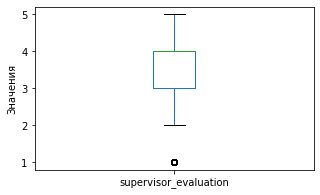

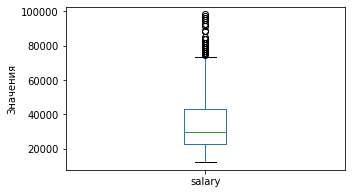

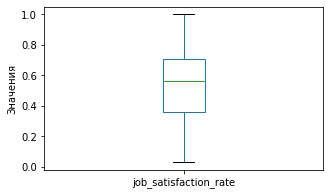

In [145]:
numeric_describe(job_satisfaction_rate)

Все выглядит адекватно, значения зарплаты в выбросах boxplot таковыми не являются, они вполне соответствуют логике этого столбца. Целевой признак действительно принимает значения от 0 до 1.

#### Обработка test_features и test_target_job_satisfaction_rate

In [146]:
test_features = del_duplicates(test_features)

Всего дубликатов: 0


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary


In [147]:
for column in test_features.select_dtypes(exclude='number').columns:
    print(column, test_features[column].unique(), '\n')

dept ['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' '] 

level ['junior' 'middle' 'sinior' nan] 

workload ['medium' 'low' 'high' ' '] 

last_year_promo ['no' 'yes'] 

last_year_violations ['no' 'yes'] 



Явных и неявных дубликатов нет. Заменим sinior на senior, а так же ' ' в столбцах на nan для корректного заполнения в дальнейшем.

In [148]:
test_features['level'] = test_features['level'].replace('sinior', 'senior', regex=True)
test_features['dept'] = test_features['dept'].replace(' ', np.nan, regex=True)
test_features['workload'] = test_features['workload'].replace(' ', np.nan, regex=True)

Установим в качестве индекса айди пользователя, поскольку никакой полезной информации для обучения он не несет.

In [149]:
test_features = test_features.set_index('id')

,supervisor_evaluation,salary
count,2000.000000,2000.000000
mean,3.526500,34066.800000
std,0.996892,15398.436729
min,1.000000,12000.000000
25%,3.000000,22800.000000
50%,4.000000,30000.000000
75%,4.000000,43200.000000
max,5.000000,96000.000000


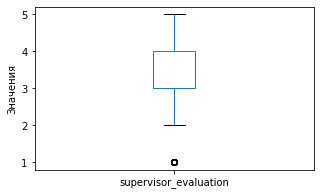

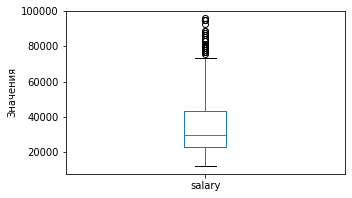

In [150]:
numeric_describe(test_features)

Все адекватно.

На всякий случай посмотрим, что целевой признак принимает значения от 0 до 1 и не выходит за границы.

In [151]:
test_target_job_satisfaction_rate.describe()

,id,job_satisfaction_rate
count,2000.000000,2000.00000
mean,552765.213500,0.54878
std,253851.326129,0.22011
min,100298.000000,0.03000
25%,339052.000000,0.38000
50%,550793.000000,0.58000
75%,765763.750000,0.72000
max,999029.000000,1.00000


Все соответствует описанию заказчика.

Установим в качестве индекса айди пользователя, так будет просто удобнее при наладке соответствия датафреймов тестовой выборки.

In [152]:
test_target_job_satisfaction_rate = test_target_job_satisfaction_rate.set_index('id')

Посмотрим на индексы в датафрейме входных признаков и таблице таргета. При несоответствии строк неверно посчитаются метрики.

In [153]:
display(test_features.head())
display(test_target_job_satisfaction_rate.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800
686555,hr,junior,medium,1,no,no,4,30000
467458,sales,middle,low,5,no,no,4,19200
418655,sales,middle,low,6,no,no,4,19200
789145,hr,middle,medium,5,no,no,5,40800


,job_satisfaction_rate
id,
130604,0.74
825977,0.75
418490,0.60
555320,0.72
826430,0.08


Индексы разбросаны хаотично, поэтому отсортируем их по возрастанию, тем самым сделаем соответствие строк входных признаков и таргета.

In [154]:
test_target_job_satisfaction_rate = test_target_job_satisfaction_rate.sort_index(ascending=True)
test_features = test_features.sort_index(ascending=True)

In [155]:
display(test_features.head())
display(test_target_job_satisfaction_rate.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200
100480,marketing,junior,low,4,no,no,4,16800
100503,purchasing,middle,high,5,no,no,4,55200
100610,sales,middle,medium,5,no,no,4,43200
100692,sales,middle,high,6,no,no,4,48000


,job_satisfaction_rate
id,
100298,0.80
100480,0.84
100503,0.79
100610,0.75
100692,0.69


Теперь все корректно.

**Вывод:**
1. В ходе обработки не было обнаружено явных и неявных признаков как в тренировочной, так и тестовой выборках.
2. Также в ходе обработки не было обнаружено аномальных значений количественных признаков.
3. Присвоили всем трем таблицам в качестве индекса id работника, также отсортировали таблицы с входными признаками и таргетами для соответствия индексов строк.

### Исследовательский анализ данных

Перед исследованием напишем функцию для построения графиков для количественных признаков.

In [156]:
def hist_box_plots(df, column):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(x=column, data=df)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=column, data=df)
    plt.show()

#### Исследование количественных признаков

Построим гистограмму и boxplot для каждого количественного признака в таблице job_satisfaction_rate.

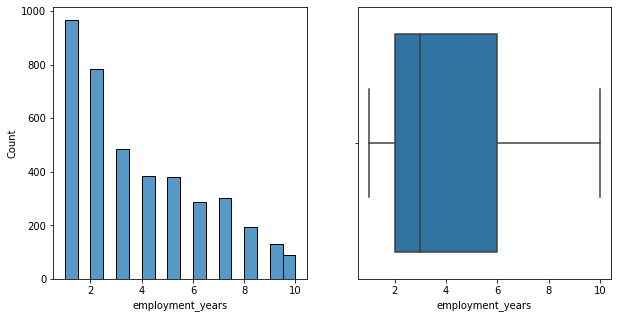

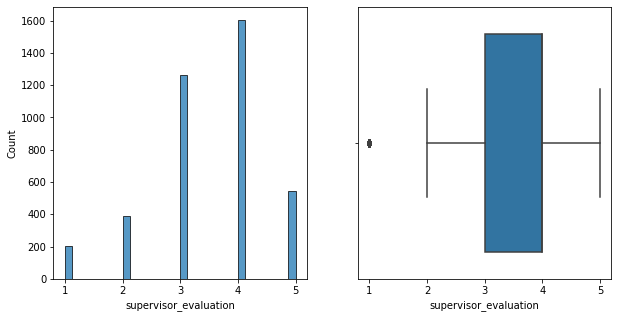

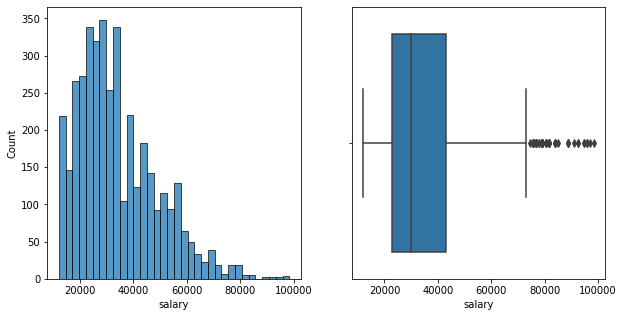

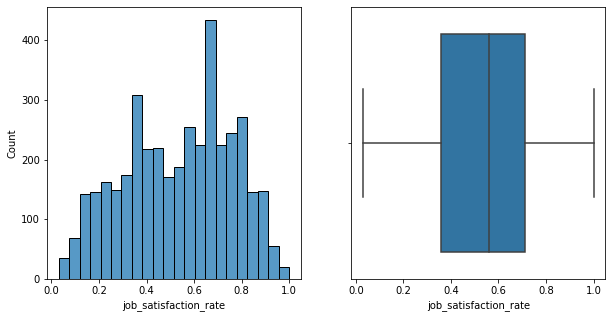

In [157]:
for column in job_satisfaction_rate.select_dtypes(include='number').columns:
    hist_box_plots(job_satisfaction_rate, column)

1. employment_years - в целом видно, что в компании большинство сотрудников с малым стажем работы(до 3 лет). в принципе это логично.
2. supervisior_evaluation - большинство оценок качества работы сотрудника равно 3 и 4.
3. salary - медиана распределения лежит в районе 30000, соответственно работников с такой зарплатой +-10000 составляют основу компании. значения выше 70000 - редкость.
4. job_satisfaction_rate - целевой признак распределен с медианой в ~0.6, в целом распределение выглядит адекватно, есть недовольные, очень довольные и средне-довольные. Причем видно, что скорее довольных(более 0.5) больше, чем скорее недовольных(<0.5)

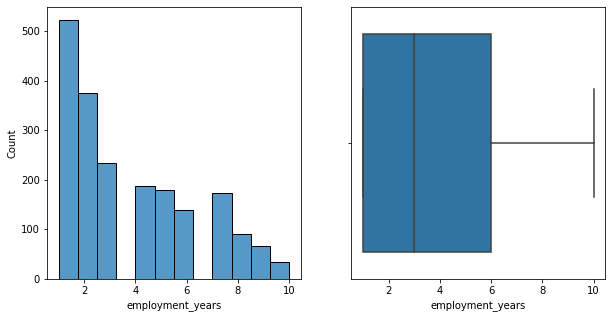

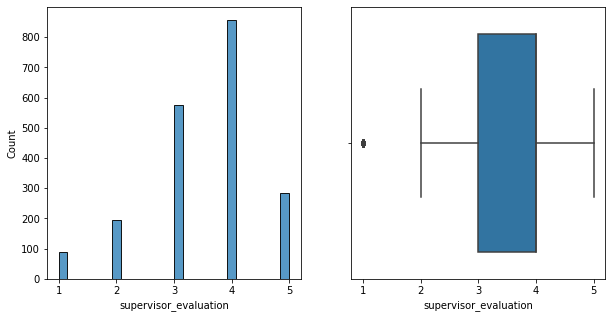

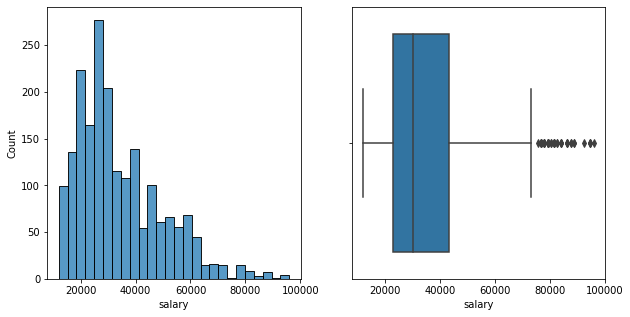

In [158]:
for column in test_features.select_dtypes(include='number').columns:
    hist_box_plots(test_features, column)

В принципе картина похожа на тренировочные данные, это значит, что в тестовых данных не должно оказаться каких-то аномальных комбинаций, ожидаем от модели хороших метрик.

#### Анализ категориальных признаков.

In [159]:
job_satisfaction_rate[job_satisfaction_rate.select_dtypes(exclude='number').columns].nunique()

dept                    5
level                   3
workload                3
last_year_promo         2
last_year_violations    2
dtype: int64

Имеем 5 категорий. По описанию будем кодировать признак level и workload рангово, то есть посредством OrdinalEncoder. Остальные признаки можно закодировать OHE.

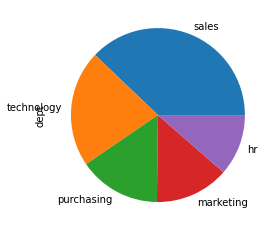

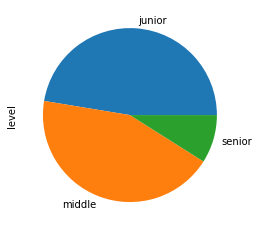

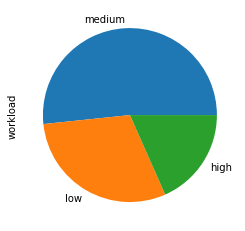

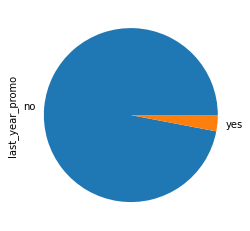

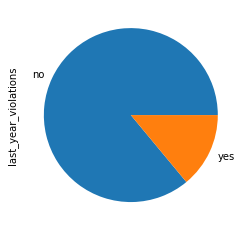

In [160]:
for category in job_satisfaction_rate.select_dtypes(exclude='number').columns:
    job_satisfaction_rate[category].value_counts().plot(kind='pie')
    plt.show()

1. dept - большая часть сотрудников работает в отделе sales, за ним следует отдел technology. в остальной доле категории распределены в целом равномерно.
2. level - почти одинаково работников с уровнем junior и middle и сравнительно мало senior - тоже все логично, senior это высокого уровня специалисты, которого не получить за 2-3 года стажа(коих большинство в компании), а junior и middle вполне вписываются в картину стажа до 3 лет.
3. workload - больше половины средне загружены(medium), за ним следует низкая нагрузка(low) и меньше всего высокая(high)
4. last_year_promo - почти никто не получал повышение из работников за прошлый год.
5. last_year_violations - все таки большая часть сотрудников соблюдают трудовой договор, но все же есть и те, кто его нарушил в прошлом году, причем таких 12-15%.

dept                    5
level                   3
workload                3
last_year_promo         2
last_year_violations    2
dtype: int64


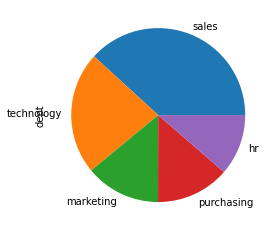

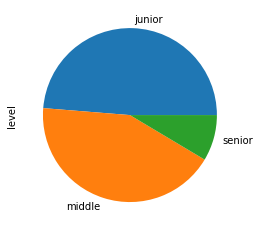

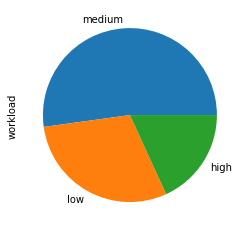

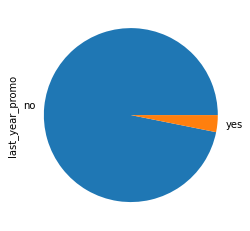

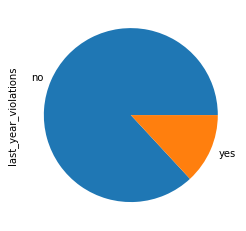

In [161]:
print(test_features[test_features.select_dtypes(exclude='number').columns].nunique())
for category in test_features.select_dtypes(exclude='number').columns:
    test_features[category].value_counts().plot(kind='pie')
    plt.show()

Все похоже на тренировочную выборку. Не стоит опасаться добавления категориального признака в debt и level - это пропуски, которые мы заполним позже.

**Вывод по исследовательской части:**
1. в компании большинство сотрудников с малым стажем работы(до 3 лет).
2. большинство оценок качества работы сотрудника равно 3 и 4.
3. медиана распределения зарплаты лежит в районе 20-40тыс., работники с такой зарплатой составляют основу компании. 
4. скорее довольных сотрудников больше, чем скорее недовольных.
5. большая часть сотрудников работает в отделе sales, за ним следует отдел technology. в остальной доле категории распределены в целом равномерно.
6. почти одинаково количество работников с уровнем junior и middle и сравнительно мало senior.
7. больше половины средне загружены, за ним следует низкая нагрузка и меньше всего высокая.
8. почти никто не получал повышение из работников за прошлый год.
9. большая часть сотрудников соблюдают трудовой договор, но все же есть и те, кто его нарушил в прошлом году, причем таких 12-15%.

**Вывод по дальнейшей обработки признаков:**
1. Количественные признаки будем кодировать как обычно StandardScaler или MinMaxScaler
2. Категориальные признаки level и workload кодируем рангово OrdinalEncoder, остальные признаки кодируем OneHotEncoder, к тому же они почти все бинарные, ну кроме dept.

### Корреляционный анализ (по собственному желанию)

Проведем корреляционный анализ признаков в количественной шкале на основе тренировочной выборки.

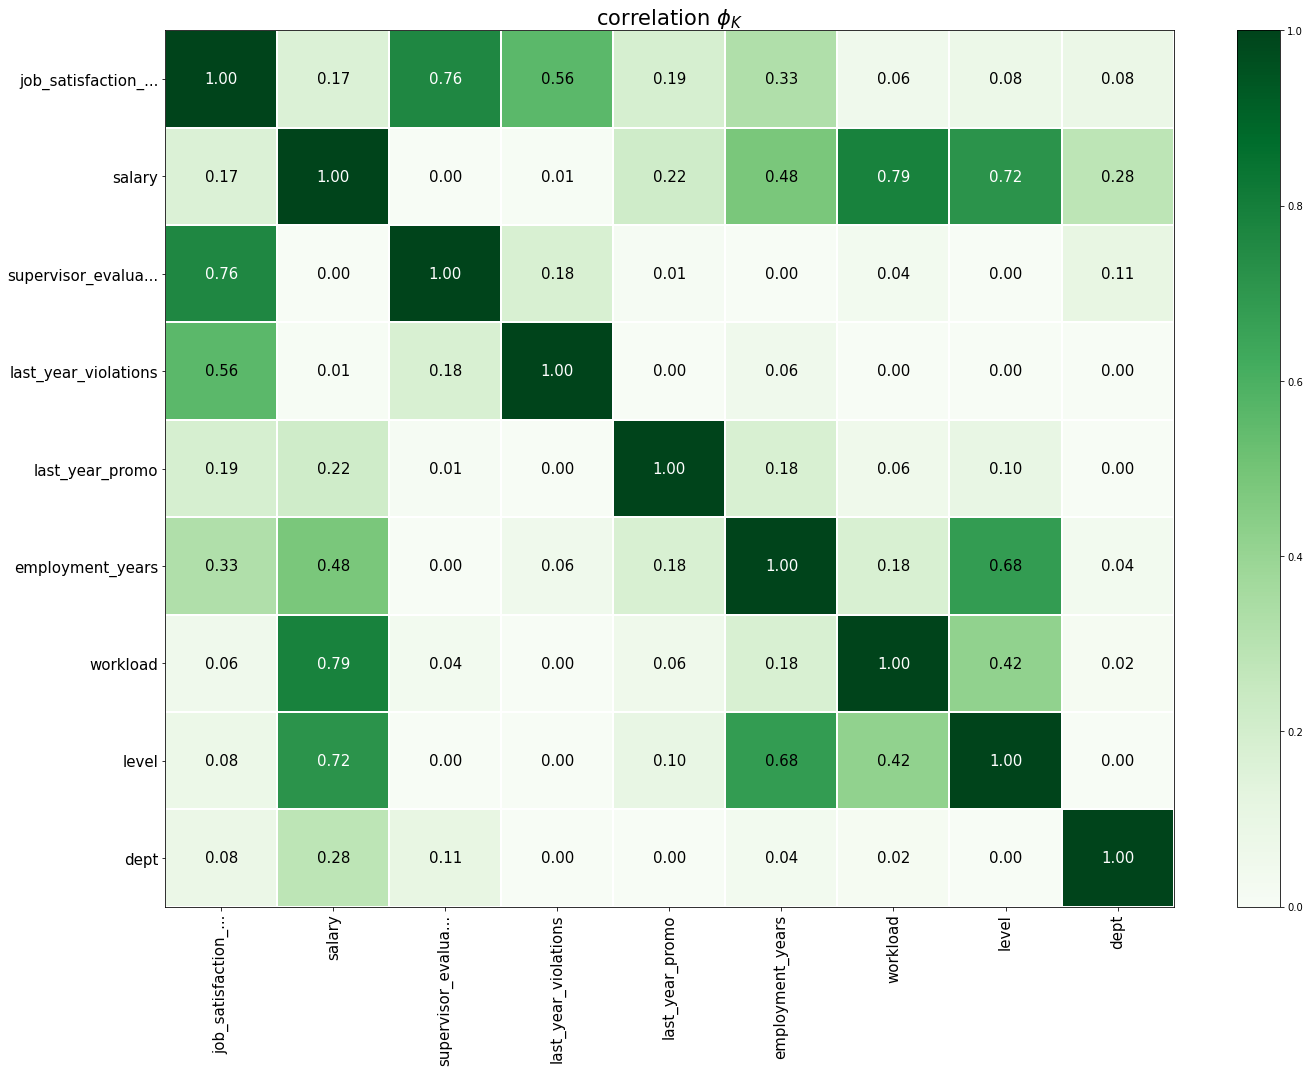

In [162]:
phik_overview = phik_matrix(job_satisfaction_rate, interval_cols=job_satisfaction_rate.select_dtypes(include='number').columns.tolist()) 
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

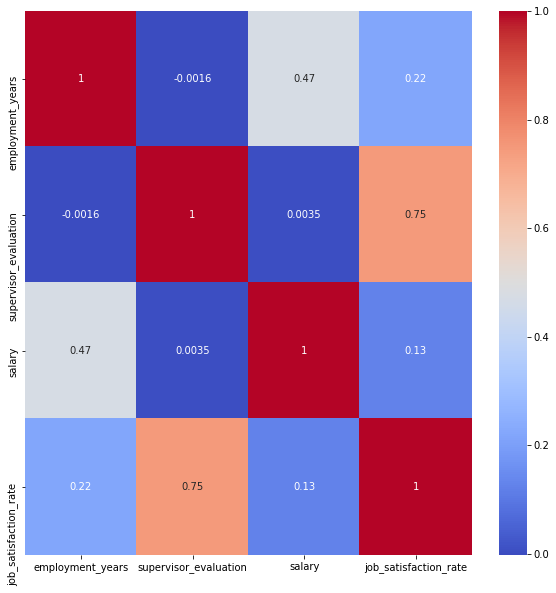

In [163]:
plt.figure(figsize = (10,10))
sns.heatmap(job_satisfaction_rate.corr(method='spearman'), annot=True, cmap='coolwarm')
plt.show()

**Вывод:**
1. Мультиколлинеарности не обнаружено
2. Больше всего целевой признак коррелирует с supervisor_evaluation - оценка качества работы сотрудника, которую дал руководитель - 0.76. Дальше идет last_year_violations - 0.56. Остальные признаки почти не коррелируют с целевым признаком.

### Подготовка данных и обучение моделей

Построим пайплайн для обучения моделей, предварительно подготовив данные.

In [164]:
X_train = job_satisfaction_rate.drop(['job_satisfaction_rate'], axis=1)
y_train = job_satisfaction_rate['job_satisfaction_rate']

In [165]:
num_columns = X_train.select_dtypes(include='number').columns.tolist()
ord_columns = ['level', 'workload']
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']

In [166]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='error', sparse=False))
    ]
    )

# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'senior'],
                    ['low', 'medium', 'high']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

In [167]:
# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns), 
     ('ord', ord_pipe, ord_columns),
     ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

In [168]:
param_grid = [
    # словарь для модели LinearRegression()
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough'] 
    },
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 12),
        'models__max_features': range(2, 9),
        'models__min_samples_leaf': range(1, 9),
        'models__min_samples_split': range(2, 9),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]

In [169]:
def custom_metric_smape(y_true, y_pred):
    metric = 100/len(y_true)*np.sum(np.abs(y_true-y_pred)/((np.abs(y_true)+np.abs(y_pred))/2))
    return metric
    
scorer_smape = make_scorer(custom_metric_smape, greater_is_better=False) 

In [170]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring=scorer_smape,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print('Метрика SMAPE лучшей модели на тренировочной выборке:', randomized_search.best_score_)

y_test_pred = randomized_search.predict(test_features)
print(f'Метрика SMAPE на тестовой выборке: {custom_metric_smape(test_target_job_satisfaction_rate["job_satisfaction_rate"], y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                              

**Вывод:** Лучшая модель оказалась DecisionTreeRegressor с методом масштабирования MinMaxScaler, а также следующими параметрами: max_depth=11, max_features=6, min_samples_leaf=2, min_samples_split=3. Вычисленные метрики:

Метрика SMAPE лучшей модели на тренировочной выборке: -15.568418648202803

Метрика SMAPE на тестовой выборке: 14.809149408716252<15 => требование заказчика выполнено.

### Вывод по первой задаче

В ходе обучения была выявлена лучшая модель - DecisionTreeRegressor с методом масштабирования MinMaxScaler, а также следующими параметрами: max_depth=11, max_features=6, min_samples_leaf=2, min_samples_split=3. Вычисленные метрики:

Метрика SMAPE лучшей модели на тренировочной выборке: -15.568418648202803 

Метрика SMAPE на тестовой выборке: 14.809149408716252<15 => требование заказчика выполнено.

Скорее всего модель DecisionTreeRegressor оказалась лучшей из-за того, что она является более гибкой и ее можно настраивать через гиперпараметры.

## Задача 2

### Загрузка данных

Загрузим данные, которые нам передал заказчик, с учетом того, что входные признаки для тестовой выборки у нас уже загружены и находятся в датафрейме test_features.

In [171]:
train_quit = pd.read_csv('/datasets/train_quit.csv')
test_target_quit = pd.read_csv('/datasets/test_target_quit.csv')

Проверяем корректность считывания

In [172]:
display(train_quit.head())
test_target_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


Все считалось корректно. Заметим, что айди для таргетов опять перемешаны, поэтому отсортируем их по индексу позже для соответствия с test_features.

Посмотрим общую информацию.

In [173]:
display(train_quit.info())
test_target_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


Типы данных соответствуют описанию столбцов, видимых пропусков нигде нет, отлично, данные на первый взгляд качественные.

**Вывод:** Успешно считали файлы для тренировочной и тестовой выборок, пропусков не было обнаружено, данные приведены верно.

### Предобработка данных

Как обычно проверим на дубликаты и неявные дубликаты, посмотрим на аномалии.

In [174]:
train_quit = del_duplicates(train_quit)

Всего дубликатов: 0


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit


Ищем неявные дубликаты в категориальных признаках.

In [175]:
for column in train_quit.select_dtypes(exclude='number').columns:
    print(column, train_quit[column].unique(), '\n')

dept ['sales' 'purchasing' 'marketing' 'technology' 'hr'] 

level ['middle' 'junior' 'sinior'] 

workload ['high' 'medium' 'low'] 

last_year_promo ['no' 'yes'] 

last_year_violations ['no' 'yes'] 

quit ['no' 'yes'] 



Явных и неявных дубликатов не обнаружено, в этом плане все корректно. Заменим sinior на senior для корректности орфографии.

In [176]:
train_quit['level'] = train_quit['level'].replace('sinior', 'senior', regex=True)

Установим в качестве индекса айди пользователя

In [177]:
train_quit = train_quit.set_index('id')

,supervisor_evaluation,salary
count,4000.000000,4000.000000
mean,3.474750,33805.800000
std,1.004049,15152.415163
min,1.000000,12000.000000
25%,3.000000,22800.000000
50%,4.000000,30000.000000
75%,4.000000,43200.000000
max,5.000000,96000.000000


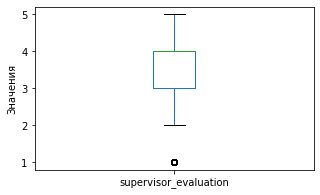

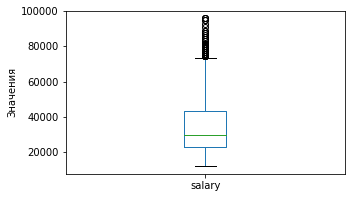

In [178]:
numeric_describe(train_quit)

Все выглядит адекватно, аномалий и выбросов нету, выбросы на боксплоте с salary таковыми не являются, все соответствует логике.

Также для тестовых таргетов установим в качестве индекса айди работника.

In [179]:
test_target_quit = test_target_quit.set_index('id')

Обработаем тестовые таргеты, а именно отсортируем их по возрастанию индекса для соответствия со строками входных признаков.

In [180]:
test_target_quit = test_target_quit.sort_index(ascending=True)

In [181]:
display(test_features.head())
test_target_quit.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200
100480,marketing,junior,low,4,no,no,4,16800
100503,purchasing,middle,high,5,no,no,4,55200
100610,sales,middle,medium,5,no,no,4,43200
100692,sales,middle,high,6,no,no,4,48000


,quit
id,
100298,no
100480,no
100503,no
100610,no
100692,no


Теперь все корректно.

**Вывод:**
1. Обработали данные, явных и неявных дубликатов не было обнаружено, данные качественные.
2. В качестве индексов для обоих таблиц указали айди, для таблицы с тестовыми таргетами сделали сортировку по возрастанию индекса для соответствия с входными признаками.

### Исследовательский анализ

#### Общий анализ

Посмотрим на диаграммы распределений и боксплоты для каждого категориального признака train_quit

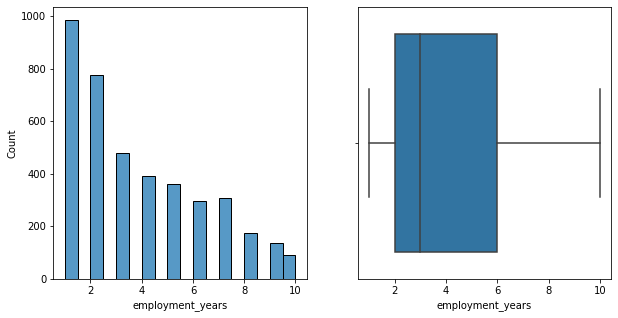

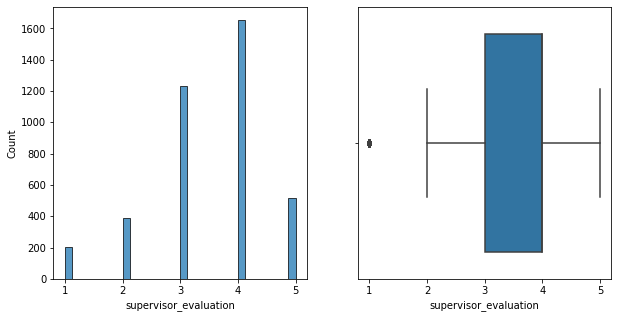

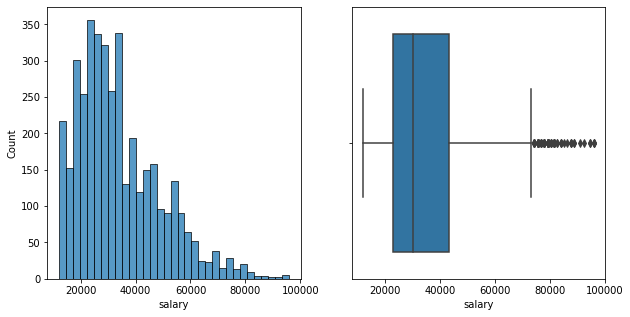

In [182]:
for column in train_quit.select_dtypes(include='number').columns:
    hist_box_plots(train_quit, column)

Данные в целом похожи на те, что мы изучали раннее(может это они и есть(?)), поэтому просто повторим выводы:
1. employment_years - в целом видно, что в компании большинство сотрудников с малым стажем работы(до 3 лет).
2. supervisior_evaluation - большинство оценок качества работы сотрудника равно 3 и 4.
3. salary - медиана распределения лежит в районе 30000, соответственно работников с такой зарплатой +-10000 составляют основу компании. значения выше 70000 - редкость.

Так как картина данных похожа на картину тренировочных данных из предыдущей задачи, то нет необходимости в выводе распределений для тестовой выборки, мы уже сделали вывод, что они похожи и нет каких-то аномалий, поэтому и в данном случае модель должна показать хорошие метрики.

Посмотрим на категориальные данные.

In [183]:
train_quit[train_quit.select_dtypes(exclude='number').columns].nunique()

dept                    5
level                   3
workload                3
last_year_promo         2
last_year_violations    2
quit                    2
dtype: int64

Как и в прошлой задаче, что логично, входные признаки для тестовой выборки совпадают, таблица не могла чем-то пополниться, но лучше предохраниться. Все то же самое - имеем 5 категорий. По описанию будем кодировать признак level и workload рангово, то есть посредством OrdinalEncoder. Остальные признаки можно закодировать OHE, кроме, конечно, целевого, оставим его как есть.

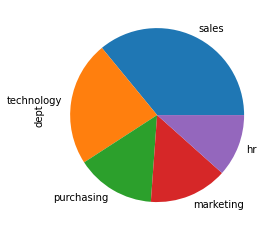

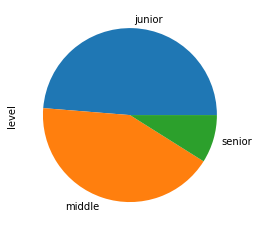

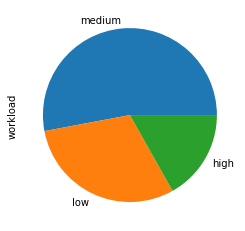

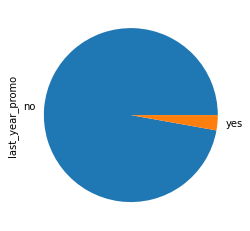

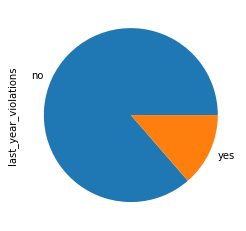

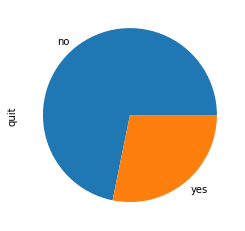

In [184]:
for category in train_quit.select_dtypes(exclude='number').columns:
    train_quit[category].value_counts().plot(kind='pie')
    plt.show()

Все как и в прошлой задаче: 
1. dept - большая часть сотрудников работает в отделе sales, за ним следует отдел technology. в остальной доле категории распределены в целом равномерно.
2. level - почти одинаково работников с уровнем junior и middle и сравнительно мало senior - тоже все логично, senior это высокого уровня специалисты, которого не получить за 2-3 года стажа(коих большинство в компании), а junior и middle вполне вписываются в картину стажа до 3 лет.
3. workload - больше половины средне загружены(medium), за ним следует низкая нагрузка(low) и меньше всего высокая(high)
4. last_year_promo - почти никто не получал повышение из работников за прошлый год.
5. last_year_violations - все таки большая часть сотрудников соблюдают трудовой договор, но все же есть и те, кто его нарушил в прошлом году, причем таких 12-15%.

Признак quit рассмотрим отдельно

In [185]:
train_quit['quit'].value_counts()

no     2872
yes    1128
Name: quit, dtype: int64

В целом вряд ли можно говорить о каком-то сильном дизбалансе классов, безусловно тех, кто уволился, меньше, было бы странно, если было наоборот, что-то тогда явно не так в этой компании, ну а так конечно учтем этот факт и если что применем параметр class_weight='balanced' для возможных моделей при обучении.

#### Портрет «уволившегося сотрудника»

Данную задачу будем решать так - разделим датасет на две части, неуволившихся и уволившихся, а затем построим для каждого по графику и будем сравнивать.

In [186]:
no_quit = train_quit[train_quit['quit']=='no']
yes_quit = train_quit[train_quit['quit']=='yes']

Сначала проанализируем количественные признаки.

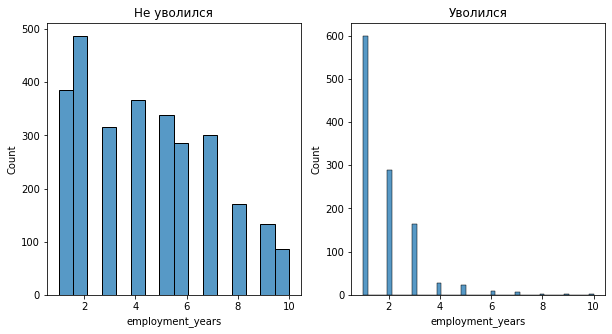

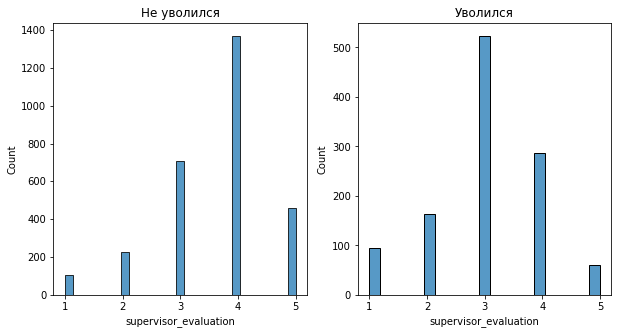

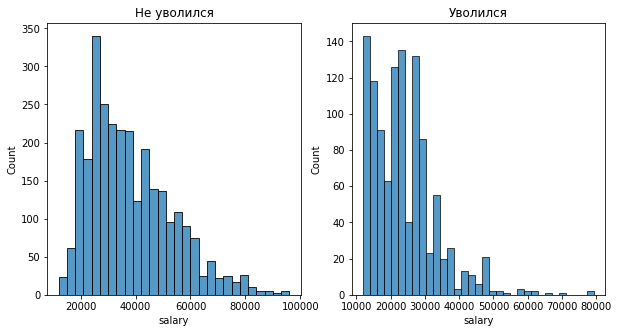

In [187]:
for column in train_quit.select_dtypes(include='number').columns.tolist():
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Не уволился')
    sns.histplot(x=column, data=no_quit)
    plt.subplot(1, 2, 2)
    plt.title('Уволился')
    sns.histplot(x=column, data=yes_quit)
    plt.show()

1. В целом видно, что увольняются работники преимущественно со стажем до 2 лет, не увольняются же работники как с малым, так и большим стажем с более равномерной долей каждого.
2. Видно, что больше всего увольняется те, у кого оценка качества работы сотрудника, которую дал руководитель равна 3. в случае не увольнявшихся видно, что больше всего оценок '4'.
3. Касаемо зарплаты довольно хорошо видно смещения пика и медианы в сторону менее 30тыс., что логично, малая зарплата часто является причиной увольнения по собственному желанию. В случае неуволившихся средняя зп находится в районе 30-40тыс. и распределена в оба хвоста равномерно.

Теперь рассмотрим категориальные признаки:

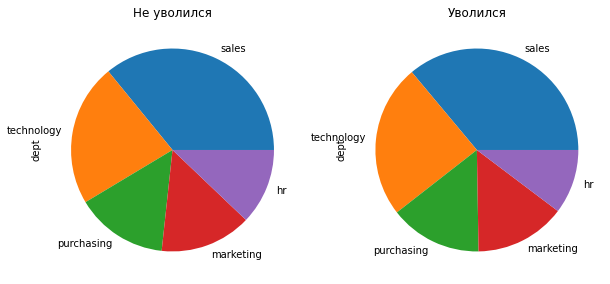

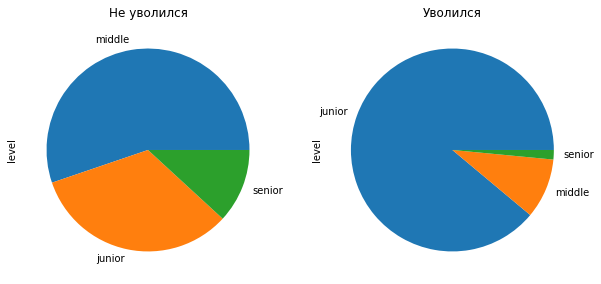

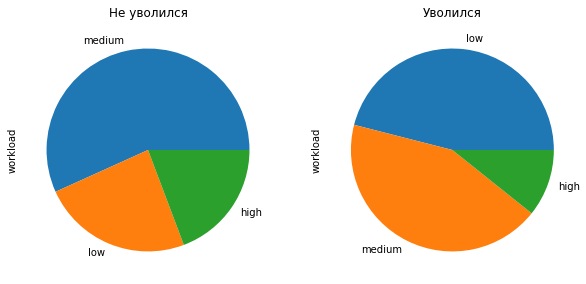

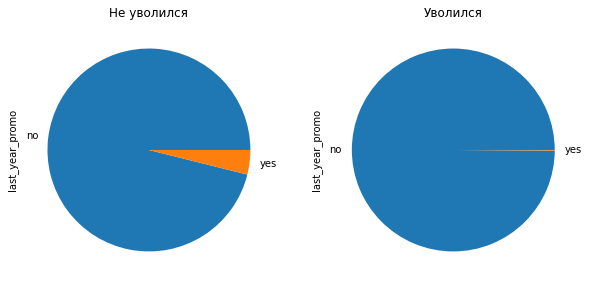

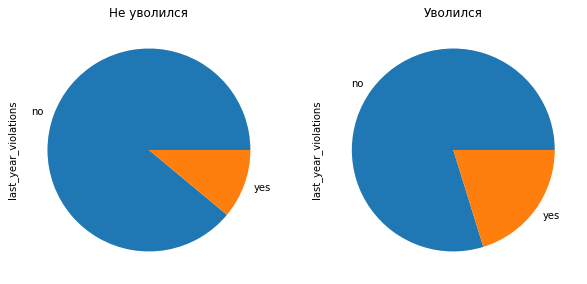

In [188]:
for category in train_quit.drop(['quit'], axis=1).select_dtypes(exclude='number').columns.tolist():
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Не уволился')
    no_quit[category].value_counts().plot(kind='pie')
    plt.subplot(1, 2, 2)
    plt.title('Уволился')
    yes_quit[category].value_counts().plot(kind='pie')
    plt.show()

1. Отдел никак не влияет на увольнение сотрудника, увольняются и не увольняются одинаково по отделам, то что в sales увольняются больше всего ни о чем не говорит, там и так больше всего сотрудников, поэтому и увольняются оттуда больше просто по математической логике.
2. Увольняются преимущественно junior работники, что соответствует выводу по количественными признакам, в котором мы подметили, что увольняются преимущественно работники со стажем до 2 лет(что и является уровнем джуна).
3. Интересная тенденция по загруженности(workload) - увольняются равномерно как те, что со средней загруженностью, как и те, что с низкой, причем не увольняются в большей степени те, кто со средней загруженностью, а не малой. также видна необычная доля по высокой загруженности - сравнительная доля неуволившихся с высокой загруженностью выше, чем доля уволившихся, хотя большая загруженность обычно сопровождается повышенной зарплатой, а это уже дает повод не увольнятся.
4. last_year_promo (показывает, было ли повышение за последний год) - вообще там и так неравномерно распределены доли, а в доли уволившихся подавно, но сделаем совершенно логичный вывод - люди, получившие повышение, почти не увольняются, в остальном плане увольняются конечно те, кто этого повышения не получал.
5. last_year_violations (показывает, нарушал ли сотрудник трудовой договор за последний год) - доля нарушивших договор и уволившихся выше в сравнительной мере доли тех же нарушивших, но не уволенных, что тоже логично - нарушил договор, значит ты не особо компетентный работник, недалеко и до увольнения. Но все же в данном признаке преимущественно увольняются те, кто договор не нарушал, но опять же, это соответствует неравномерному распределению классов, поэтому тут вывод стоит акцентировать на разнице долей нарушивших договор по уволенным и нет.

Посчитаем долю уволившихся по отделам.

In [210]:
for category in train_quit['dept'].unique().tolist():
    print(f'Общее количество работников в {category}: {train_quit["dept"].value_counts()[category]}')
    print(f'Количество уволенных: {yes_quit["dept"].value_counts()[category]}; доля уволенных: {round(yes_quit["dept"].value_counts()[category]/train_quit["dept"].value_counts()[category], 2)}\n')

Общее количество работников в sales: 1438
Количество уволенных: 407; доля уволенных: 0.28

Общее количество работников в purchasing: 588
Количество уволенных: 166; доля уволенных: 0.28

Общее количество работников в marketing: 582
Количество уволенных: 163; доля уволенных: 0.28

Общее количество работников в technology: 928
Количество уволенных: 276; доля уволенных: 0.3

Общее количество работников в hr: 464
Количество уволенных: 116; доля уволенных: 0.25



Видно, что больше всего доля уволившихся в отделе technology - 0.30, в sales, purchasing, marketing считай поровну - 0.28, меньше всего в отделе hr - 0.25. Но в целом значения несильно отличаются друг от друга, хотя 0.30 и 0.25 это целых 5%, может и значимая цифра.

**На основе двух выводов составим портет "уволившегося сотрудника":**
1. Зарплата в районе 10-30тыс.
2. Стаж до 2 лет, то есть junior работник.
3. Загружен средне или мало (видимо не видит развития в работе, поэтому из-за малой загруженности увольняется).
4. Не получал повышения за последний год.
5. Нарушил трудовой договор за последний год.
6. С вероятностью в 30% работает в technology.

#### Сравнение распределения признака job_satisfaction_rate для ушедших и оставшихся сотрудников

Аналитики утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Проверим это утверждение: визуализируем и сравним распределения признака job_satisfaction_rate для ушедших и оставшихся сотрудников. 

In [189]:
quit_sat_data = test_target_job_satisfaction_rate.join(test_target_quit, how='inner')

In [190]:
quit_sat_data.head()

,job_satisfaction_rate,quit
id,,
100298,0.80,no
100480,0.84,no
100503,0.79,no
100610,0.75,no
100692,0.69,no


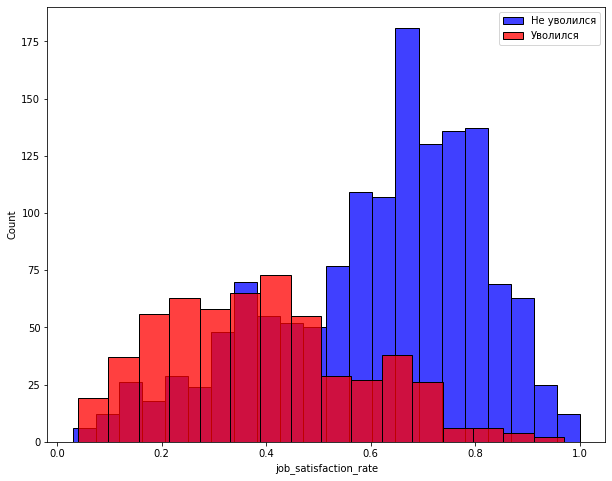

In [191]:
plt.figure(figsize=(10, 8))
sns.histplot(data=quit_sat_data[quit_sat_data['quit']=='no'], x='job_satisfaction_rate', color='blue')
sns.histplot(data=quit_sat_data[quit_sat_data['quit']=='yes'], x='job_satisfaction_rate', color='red')
plt.legend(['Не уволился', 'Уволился']) 
plt.show()

В целом видно, что присутствует взаимосвязь между удовлетворенностью работой и увольнением - основная часть уволившихся лежит левее 0.6(<0.6) по шкале удовлетворенности, при этом оставшиеся работники в сравнительном большинстве удовлетворены работой и лежат правее значений 0.5(>0.5) по шкале удовлетворенности.

### Добавление нового входного признака

Добавим job_satisfaction_rate, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.

In [192]:
train_quit['job_satisfaction_rate'] = randomized_search.predict(train_quit.drop(['quit'], axis=1))

In [193]:
train_quit.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
id,,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no,0.617579
814010,sales,junior,medium,2,no,no,4,27600,no,0.834831
155091,purchasing,middle,medium,5,no,no,1,37200,no,0.471250
257132,sales,junior,medium,2,no,yes,3,24000,yes,0.340000
910140,marketing,junior,medium,2,no,no,5,25200,no,0.810213


In [194]:
test_features['job_satisfaction_rate'] = y_test_pred

In [195]:
test_features.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200,0.837561
100480,marketing,junior,low,4,no,no,4,16800,0.818571
100503,purchasing,middle,high,5,no,no,4,55200,0.773901
100610,sales,middle,medium,5,no,no,4,43200,0.805697
100692,sales,middle,high,6,no,no,4,48000,0.773901


Добавление выполнено успешно.

### Подготовка данных и обучение моделей

Подготовим данные и дополним пайплайн. Дропнем dept, поскольку он не влияет на увольнение и будет только мешать обучению.

In [196]:
X_train_2 = train_quit.drop(['quit', 'dept'], axis=1)
y_train_2 = train_quit['quit']
X_test_2 = test_features.drop(['dept'], axis=1)

Сделаем новый список столбцов с учетом изменений.

In [197]:
num_columns = X_train_2.select_dtypes(include='number').columns.tolist()
ord_columns = ['level', 'workload']
ohe_columns = ['last_year_promo', 'last_year_violations']

In [202]:
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns), 
     ('ord', ord_pipe, ord_columns),
     ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [203]:
param_grid_new = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 5),
        'models__max_features': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    },
    
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 100, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']   
    },

    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    }
]

In [204]:
randomized_search_new = RandomizedSearchCV(
    pipe_final, 
    param_grid_new, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search_new.fit(X_train_2, y_train_2)

print('Лучшая модель и её параметры:\n\n', randomized_search_new.best_estimator_)
print('Метрика roc_auc лучшей модели на тренировочной выборке:', randomized_search_new.best_score_)

y_test_proba = randomized_search_new.predict_proba(X_test_2)[:,1]
print(f'Метрика roc_auc на тестовой выборке: {roc_auc_score(test_target_quit["quit"], y_test_proba)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse=False))]),
                                                  ['last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                      

Метрика roc_auc на тестовой выборке: 0.9211672000632173>0.91 => требования заказчика выполнены.

### Вывод

В ходе обучения лучшей моделью оказалась KNeighborsClassifier c n_neighbors=22 и кодированием StandardScaler. Вычисленные метрики:

Метрика roc_auc лучшей модели на тренировочной выборке: 0.9311059026276075

Метрика roc_auc на тестовой выборке: 0.9211672000632173>0.91 => требования заказчика выполнены.

Почему эта модель оказалась лучшей среди трех(дерево, логистическая регрессия и собственно KNeighborsClassifier) сложно сказать, видимо входные признаки изначально хорошо описывают уволится работник или нет, поэтому особых действий с ними не нужно производить как в дереве или нахождение коэффициентов в логистической регрессии, достаточно определить ближайших соседей по значениям и дело сделано, 92% на метрике это очень хорошо.

## Общий вывод

В этой работе перед нами были поставлены следующие задачи:
1. Построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика.
2. Построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

Для их достижения мы прошли через несколько этапов:
1. Загрузили данные, полученные от заказчика. В целом данные были достаточно качественные с минимум пропусков. Названия столбцов были приятными на взгляд - snake_case.
2. Предобработали данные, посмотрели на наличие дубликатов, их не было обнаружено, как и аномальных значений. В этом плане все было качественно, за исключением одной орфографической ошибки sinior, но это вообще некритично.
3. Провели исследовательский анализ данных.
4. Провели корреляционный анализ(для первой задачи).
5. Обработали данные и построили пайплайны для двух задач.
6. Выделили лучшие модели и выполнили требования заказчика по метрикам.

Теперь по моделям и задачам:
1. Модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика:

лучшая модель - LinearRegression с методом масштабирования StandardScaler. Метрики:

Метрика SMAPE лучшей модели на тренировочной выборке: -6.257113736551774

Метрика SMAPE на тестовой выборке: 5.907561837835684, что меньше 15, требование заказчика выполнено.

2. Модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании:

лучшая модель KNeighborsClassifier c n_neighbors=22 и кодированием StandardScaler. Вычисленные метрики:

Метрика roc_auc лучшей модели на тренировочной выборке: 0.9315167664444631

Метрика roc_auc на тестовой выборке: 0.9222475750212371>0.91 => требования заказчика выполнены.

В результате мы успешно справились с поставленной работой.

**Рекомендации для бизнеса:**

Вернемся к нашему портрету "уволившегося сотрудника":
1. Зарплата в районе 10-30тыс.
2. Стаж до 2 лет, то есть junior работник.
3. Загружен средне или мало (видимо не видит развития в работе, поэтому из-за малой загруженности увольняется).
4. Не получал повышения за последний год.
5. Нарушил трудовой договор за последний год.
6. С вероятностью в 30% работает в technology.

На основе этого можно вынести следующие рекомендации:
1. Быть более лояльным в отношении зарплаты и повышения. Как мы видели, очень мало сотрудников получило повышение, это может приводить к стагнации работника, он будет ощущать несправедливость по отношению к себе, не будет видеть карьерного роста и уволится. Соответственно, чтобы этого избежать, нужно больше повышать сотрудников и соответственно более охотно повышать зарплату(конечно тем, кто этого заслужил)
2. Необходимо удерживать новых сотрудников, опять же как-то более охотно повышать их, показывать перспективы развития в вашей компании, в общем заинтересовать их в работе именно в вашей компании.
3. Если сотрудник загружен мало, он может чувствовать застой в развитии и не увидит перспективы работы в вашей компании. Соответственно следует выдавать больше интересных кейсов и задач, которые помогут не только компании, но и в развитии сотрудника. Также можно предлагать сотрудникам какое-то доп развитие или курсы вне работы.